In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator

## Upwelling Indices Comparison

* Multiple Wind, Nitrogen and SST based Upwelling Indices are compared at the Northern Humboldt Upwelling System

* * Bakun Upwelling Index
  * CUTI
  * BEUTI
  * Analytical Velocity
  * Ekman terms (Ek pump + Offshore Ekman cross-shore transport) -- Total Wind Upwelling Contributio (TWUC)
  * CUI
  * Surface Chlorophyll-a

### Pre processed

In [2]:
#### Inshore mask
## kml to struct
import re
from xml.etree import ElementTree as ET
import numpy as np

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [3]:
arch_kml_zona1 = "/gxfs_work/geomar/smomw662/NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [4]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

ds_ = xr.open_dataset('../../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})

mask_rho = ds_.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

/tmp/ipykernel_538233/70548169.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


In [5]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK100km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [6]:

##------CUI_model
CUI = loadmat("../../../NHCS/Processed/CUI_SST_index.mat")
CUI_cc = np.array(CUI['CUI_SSTi']).squeeze()
lati_cc = np.array(CUI['lati']).squeeze()

CUI_ds = xr.DataArray(
    data=CUI_cc.T,  # numpy array of Mean_CUI
    dims=["time",'lat'],  # Dimension matches the time in CUI_MAX
    coords={"time": time,
           'lat': lati_cc},  # Ensure matching time coordinates
    name="CUI_cc"  # Name for the variable
)

In [7]:
## jacox lat_band
def lat_band_mean(
    f,
    lat_top_start=-5,
    lat_top_end=-16,
):
    """
    Compute (f_north + f_south)/2 for successive 1° latitude bands.

    Parameters
    ----------
    f : xarray.DataArray
        Must have a 'lat' dimension (and optionally time/lon/etc.).
    lat_top_start : float or int
        Northern latitude of the first band (e.g. -5).
    lat_top_end : float or int
        Northern latitude of the last band (e.g. -16).

    Returns
    -------
    f_band : xarray.DataArray
        delta_f for each 1° band, with new dimension 'lat_band'.
        Any other original dimensions (e.g. time) are preserved.
    """

    delta_f = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):
        lat_south = lat_north - 1

        # 1° band slice
        f_band = f.sel(lat=slice(lat_south, lat_north))

        # skip bands with no points
        if f_band.sizes.get("lat", 0) == 0:
            continue

        southernmost = f_band.min(dim="lat", skipna=True)
        northernmost = f_band.max(dim="lat", skipna=True)

        delta_f.append((northernmost + southernmost) / 2)
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # concat over bands
    f_out = xr.concat(delta_f, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))
    f_out.name = "delta_f"

    return f_out

In [8]:
WMLD_data = loadmat("../../../NHCS/Processed/WMLD_MLD.mat")
WMLD_ds = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)*expanded_mask*inshore_mask),
    },
    coords = {
        'lon':ds_.lon_rho.compute().values[0,:],
        'lat':ds_.lat_rho.compute().values[:,0],
        'time':time
}
)

WMLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    WMLD     (time, lat, lon) float64 1GB nan nan nan nan ... nan nan nan nan

In [9]:
## jacox definition of W_mld
from tqdm import tqdm 
wj = lat_band_mean(WMLD_ds.WMLD,
    lat_top_start=-5,
    lat_top_end=-16,
)

100%|███████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 128.74it/s]


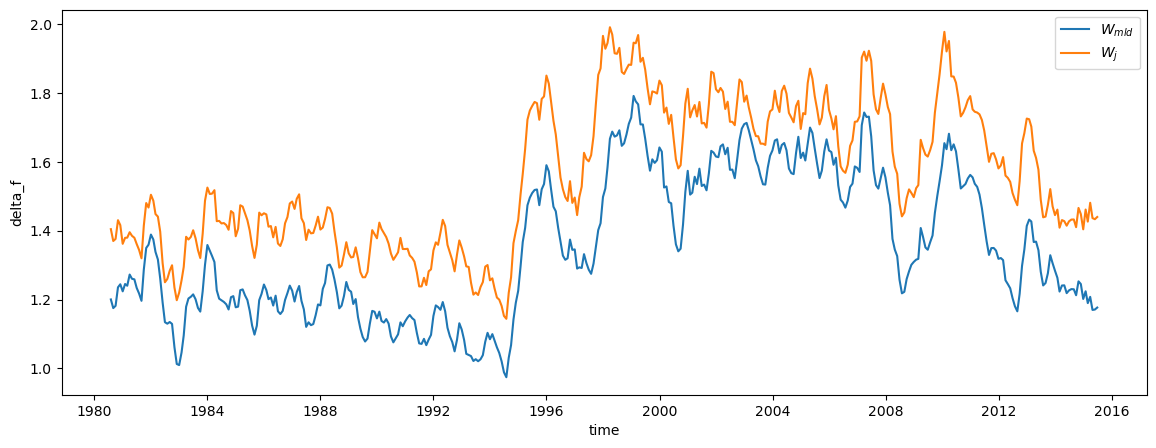

In [10]:
wmld = (WMLD_ds*111e3).sel(lat=slice(-16,-5)).mean(dim=('lon','lat'))

wmld.WMLD.rolling(time=13,center=True).mean().plot(label='$W_{mld}$',figsize=(14,5))
(wj*111e3).mean(dim=('lon','lat_band')).rolling(time=13,center=True).mean().plot(label='$W_j$')
plt.legend()

### Functions

In [11]:
## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

### Upwelling Indices

In [12]:
## Upwelling indices
AV = xr.open_dataset('AV/AV_H.nc')
BUI = xr.open_dataset('BUI/BUI_H.nc')
CUTI = xr.open_dataset('CUTI/CUTI.nc').CUTI
BEUTI = xr.open_dataset('CUTI/BEUTI.nc').BEUTI
CUI = CUI_ds.sel(lat=slice(-16,-5))

#Chlorphyll
CHL = xr.open_dataset('../../../NHCS/hincast_1980-2015/Chlorophyll.nc').drop_vars('s_rho').sel(lat=slice(-16,-5)).mean('lon')

##Ekman terms
Pump = xr.open_dataset('Ekman_Pumping/Ekman_pumping_H.nc')
Off_Ek = xr.open_dataset('Ekman_crosshore/Ek_offshore_H.nc')
#-------- Total wind driven contribution (Bravo et al., 2016)
TWDU = ((Pump.shift(lat=1) + Pump)*0.5).w_ek.dropna('lat').data + Off_Ek.Ek_offshore.data

TWDU_ds = xr.Dataset(
    data_vars={
        'TWDU': (("time","lat"), TWDU),
        'Pump': (("time","lat"), ((Pump.shift(lat=1) + Pump)*0.5).w_ek.dropna('lat').data),
        'Off_ek': (("time","lat"),Off_Ek.Ek_offshore.data),
    },
    coords = {
        'time': Pump.time,
        'lat':Off_Ek.lat,
}
)


## Seasonal scale

In [13]:
wmld_ = seasonality(wmld)
AV_=seasonality(AV.mean('lat'))
BUI_=seasonality(BUI.mean('lat'))
CUTI_=seasonality(CUTI.mean(dim=('lon','lat_band')))
BEUTI_=seasonality(BEUTI.mean(dim=('lon','lat_band')))
CUI_=seasonality(CUI.mean('lat'))
CHL_=seasonality(CHL.mean('lat'))
TWDU_=seasonality(TWDU_ds.mean('lat'))

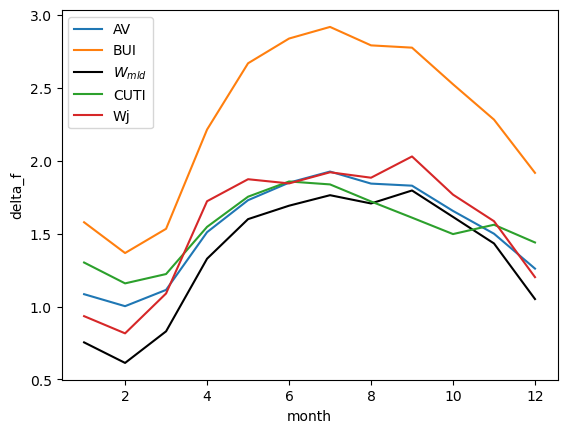

In [14]:
AV_.AV.plot(label='AV')
BUI_.BUI.plot(label='BUI')
wmld_.WMLD.plot(label='$W_{mld}$',color='black')
# TWDU_.TWDU.plot(label='TWDU')
# TWDU_.Pump.plot(label='Pump')
# TWDU_.Off_ek.plot(label='Off_Ekman')
CUTI_.plot(label='CUTI')
seasonality((wj*111e3).mean(dim=('lon','lat_band'))).plot(label='Wj')
# BEUTI_.plot()
# CHL_.chla.plot()
# CUI_.plot()
plt.legend()

In [15]:
AVs = AV_.AV.data
BUIs = BUI_.BUI.data
wmlds = wmld_.WMLD.data
wjs=seasonality((wj*111e3).mean(dim=('lon','lat_band'))).data
CUTIs = CUTI_.data
BEUTIs = BEUTI_.data
CHLs = CHL_.chla.data
CUIs = CUI_.data

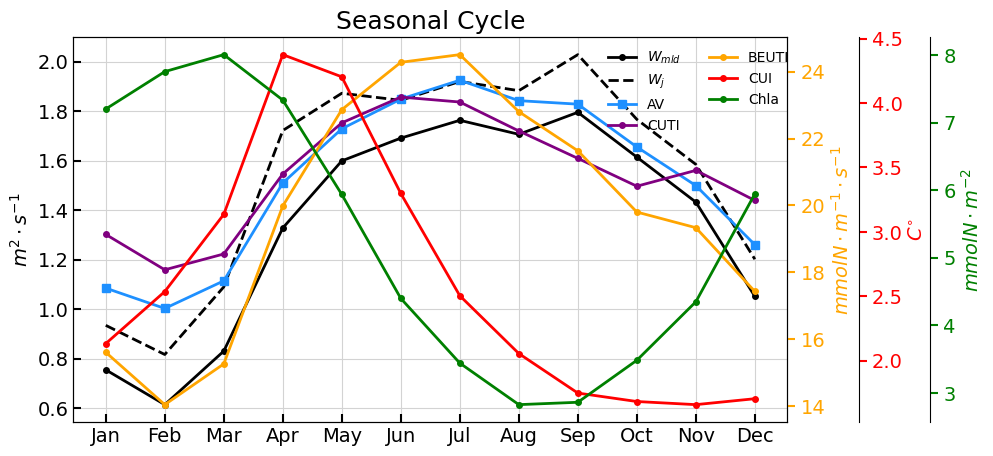

In [58]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

fig, host = plt.subplots(figsize=(12, 5))

# create extra y axes
par1 = host.twinx()
par2 = host.twinx()
par3 = host.twinx()

# offset the extra right spines
par2.spines["right"].set_position(("axes", 1.1))
par3.spines["right"].set_position(("axes", 1.2))

# make their patch/spines invisible (so only the right spine shows)
make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)

par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)

# Plotting (ensure each plot sets label)
W,   = host.plot(wmld_.month, wmlds,  linewidth=2, marker='o', markersize=4, color='black',     label='$W_{mld}$')
Wj,  = host.plot(wmld_.month, wjs,  linewidth=2, linestyle='dashed', color='black',     label='$W_{j}$')
AVi, = host.plot(wmld_.month, AVs,    linewidth=2, marker='s', markersize=6, color='dodgerblue', label='AV')
BUi, = host.plot(wmld_.month, BUIs,   linewidth=2, marker='d', markersize=6, color='royalblue',  label='BUI')
CUTi,= host.plot(CUTI_.month, CUTIs,  linewidth=2, marker='o', markersize=4, color='purple',      label='CUTI')

BEUTi, = par1.plot(BEUTI_.month, BEUTIs, linewidth=2, marker='o', markersize=4, color='orange', label='BEUTI')
CUi,   = par2.plot(CUI_.month,   CUIs,   linewidth=2, marker='o', markersize=4, color='red',    label='CUI')
Chli,  = par3.plot(CUI_.month,   CHLs,   linewidth=2, marker='o', markersize=4, color='green',  label='Chla')

# Labels
# host.set_xlabel('Time')
host.set_ylabel('$m^{2} \cdot s^{-1}$',fontsize=14)
par1.set_ylabel('$mmol N \cdot m^{-1} \cdot s^{-1}$',fontsize=14)
par2.set_ylabel('$C^{\circ}$',fontsize=14)
par3.set_ylabel('$mmol N \cdot m^{-2}$',fontsize=14)

host.yaxis.label.set_color('black')
par1.yaxis.label.set_color('orange')
par2.yaxis.label.set_color('red')
par3.yaxis.label.set_color('green')

# ticks and minor locators
tkw = dict(size=6, width=1.5)
host.xaxis.set_minor_locator(MultipleLocator(100))
host.yaxis.set_minor_locator(MultipleLocator(10))
par1.yaxis.set_minor_locator(MultipleLocator(10))
par2.yaxis.set_minor_locator(MultipleLocator(100))
par3.yaxis.set_minor_locator(MultipleLocator(100))

host.tick_params(axis='y', colors='black', **tkw, labelsize=14)
par1.tick_params(axis='y', colors='orange', **tkw, labelsize=14)
par2.tick_params(axis='y', colors='red', **tkw, labelsize=14)
par3.tick_params(axis='y', colors='green', **tkw, labelsize=14)
host.tick_params(direction='in', **tkw)

# Build legend by collecting handles/labels from all axes
h_host, l_host = host.get_legend_handles_labels()
h_p1, l_p1 = par1.get_legend_handles_labels()
h_p2, l_p2 = par2.get_legend_handles_labels()
h_p3, l_p3 = par3.get_legend_handles_labels()

handles = h_host + h_p1 + h_p2 + h_p3
labels  = l_host + l_p1 + l_p2 + l_p3

# Place legend to the right of the axes
# host.legend(handles, labels, fontsize=10,
#             loc='upper right')
fig.subplots_adjust(right=0.72)

legend = host.legend(
    handles, labels,
    fontsize=10,
    ncol=2,
    # title='Upwelling indices',
    title_fontsize=12,
    frameon=False,
    loc='upper right',
    bbox_to_anchor=(1.02, 1.0)  # optional: place it outside to the right
)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
host.set_xticks(range(1, 13))
host.set_xticklabels(months, fontsize=14)

host.grid(True, color='lightgrey', zorder=0)

# ensure host grid is drawn below the plotted lines
host.set_axisbelow(True)
plt.title('Seasonal Cycle',fontsize=18)

# plt.savefig('Figures/Seasonal_cycle_noBUI.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()


## Interannual scale

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


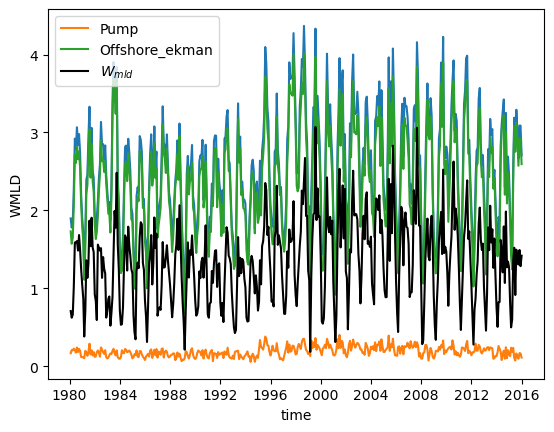

In [17]:
TWDU_ds.mean('lat').resample(time='1M').mean().sel(time=slice('1980-01-01','2015-12-31')).TWDU.plot()
TWDU_ds.mean('lat').resample(time='1M').mean().sel(time=slice('1980-01-01','2015-12-31')).Pump.plot(label='Pump')
TWDU_ds.mean('lat').resample(time='1M').mean().sel(time=slice('1980-01-01','2015-12-31')).Off_ek.plot(label='Offshore_ekman')
wmld.WMLD.sel(time=slice('1980-01-01','2015-12-31')).plot(color='black',label='$W_{mld}$')
plt.legend()

In [59]:
AV_m=AV.mean('lat').resample(time='1M').mean().AV.sel(time=slice('1980-01-01','2015-12-31')).data
BUI_m=BUI.mean('lat').resample(time='1M').mean().BUI.sel(time=slice('1980-01-01','2015-12-31')).data
wmld_m = wmld.WMLD.sel(time=slice('1980-01-01','2015-12-31')).data
wj_m= (wj*111e3).mean(dim=('lon','lat_band')).data
CUTI_m=CUTI.mean(dim=('lat_band','lon')).sel(time=slice('1980-01-01','2015-12-31')).data
BEUTI_m=BEUTI.mean(dim=('lat_band','lon')).sel(time=slice('1980-01-01','2015-12-31')).data
CUI_m=CUI.mean('lat').resample(time='1M').mean().sel(time=slice('1980-01-01','2015-12-31')).data
CHL_m=CHL.mean('lat').resample(time='1M').mean().chla.sel(time=slice('1980-01-01','2015-12-31')).data

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [60]:
time = wmld.WMLD.sel(time=slice('1980-01-01','2015-12-31')).time
time

<xarray.DataArray 'time' (time: 432)> Size: 3kB
array(['1980-01-31T00:00:00.000000000', '1980-02-29T00:00:00.000000000',
       '1980-03-31T00:00:00.000000000', ..., '2015-10-31T00:00:00.000000000',
       '2015-11-30T00:00:00.000000000', '2015-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

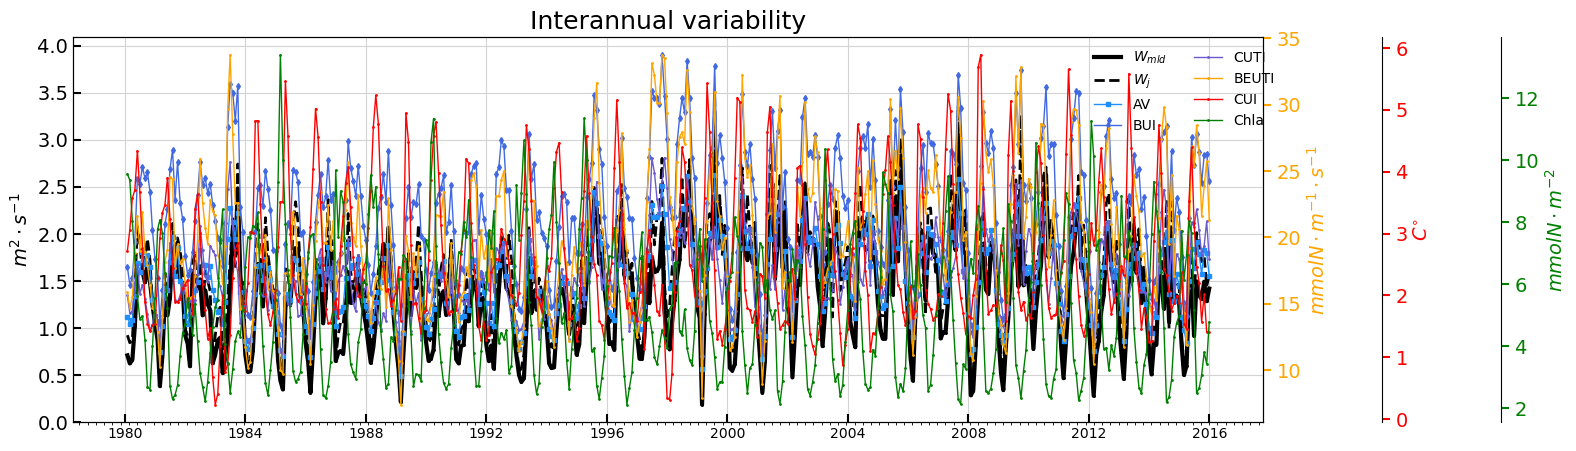

In [61]:
fig, host = plt.subplots(figsize=(20, 5))

# create extra y axes
par1 = host.twinx()
par2 = host.twinx()
par3 = host.twinx()

# offset the extra right spines
par2.spines["right"].set_position(("axes", 1.1))
par3.spines["right"].set_position(("axes", 1.2))

# make their patch/spines invisible (so only the right spine shows)
make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)

par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)

# Plotting (ensure each plot sets label)
W,   = host.plot(time, wmld_m,  linewidth=3, marker='o', markersize=1, color='black',     label='$W_{mld}$') #
Wj, =  host.plot(time, wj_m,  linewidth=2, linestyle='dashed', color='black',     label='$W_{j}$')
AVi, = host.plot(time, AV_m,    linewidth=1, marker='s', markersize=3, color='dodgerblue', label='AV')
BUi, = host.plot(time, BUI_m,   linewidth=1, marker='d', markersize=3, color='royalblue',  label='BUI')
CUTi,= host.plot(time, CUTI_m,  linewidth=1, marker='o', markersize=1, color='slateblue',      label='CUTI')

BEUTi, = par1.plot(time, BEUTI_m, linewidth=1, marker='o', markersize=1, color='orange', label='BEUTI')
CUi,   = par2.plot(time,   CUI_m,   linewidth=1, marker='o', markersize=1, color='red',    label='CUI')
Chli,  = par3.plot(time,   CHL_m,   linewidth=1, marker='o', markersize=1, color='green',  label='Chla')

# Labels
# host.set_xlabel('Time')
host.set_ylabel('$m^{2} \cdot s^{-1}$',fontsize=14)
par1.set_ylabel('$mmol N \cdot m^{-1} \cdot s^{-1}$',fontsize=14)
par2.set_ylabel('$C^{\circ}$',fontsize=14)
par3.set_ylabel('$mmol N \cdot m^{-2}$',fontsize=14)

host.yaxis.label.set_color('black')
par1.yaxis.label.set_color('orange')
par2.yaxis.label.set_color('red')
par3.yaxis.label.set_color('green')

# ticks and minor locators
tkw = dict(size=6, width=1.5)
host.xaxis.set_minor_locator(MultipleLocator(100))
host.yaxis.set_minor_locator(MultipleLocator(10))
par1.yaxis.set_minor_locator(MultipleLocator(10))
par2.yaxis.set_minor_locator(MultipleLocator(100))
par3.yaxis.set_minor_locator(MultipleLocator(100))

host.tick_params(axis='y', colors='black', **tkw, labelsize=14)
par1.tick_params(axis='y', colors='orange', **tkw, labelsize=14)
par2.tick_params(axis='y', colors='red', **tkw, labelsize=14)
par3.tick_params(axis='y', colors='green', **tkw, labelsize=14)
host.tick_params(direction='in', **tkw)

# Build legend by collecting handles/labels from all axes
h_host, l_host = host.get_legend_handles_labels()
h_p1, l_p1 = par1.get_legend_handles_labels()
h_p2, l_p2 = par2.get_legend_handles_labels()
h_p3, l_p3 = par3.get_legend_handles_labels()

handles = h_host + h_p1 + h_p2 + h_p3
labels  = l_host + l_p1 + l_p2 + l_p3

# Place legend to the right of the axes
# host.legend(handles, labels, fontsize=10,
#             loc='upper right')
fig.subplots_adjust(right=0.72)

legend = host.legend(
    handles, labels,
    fontsize=10,
    ncol=2,
    # title='Upwelling indices',
    title_fontsize=12,
    frameon=False,
    loc='upper right',
    bbox_to_anchor=(1.02, 1.0)  # optional: place it outside to the right
)

# months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
#           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# host.set_xticks(range(1, 13))
# host.set_xticklabels(months, fontsize=14)

host.grid(True, color='lightgrey', zorder=0)

# ensure host grid is drawn below the plotted lines
host.set_axisbelow(True)
plt.title('Interannual variability',fontsize=18)

# plt.savefig('Figures/Seasonal_cycle_.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

In [62]:
AV_m=AV.mean('lat').resample(time='1M').mean().AV.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().data
BUI_m=BUI.mean('lat').resample(time='1M').mean().BUI.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().data
wmld_m = wmld.WMLD.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13).mean().data
wj_m = (wj*111e3).mean(dim=('lon','lat_band')).rolling(time=13).mean().data
CUTI_m=CUTI.mean(dim=('lon','lat_band')).sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().data
BEUTI_m=BEUTI.mean(dim=('lon','lat_band')).sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().data
CUI_m=CUI.mean('lat').resample(time='1M').mean().sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().data
CHL_m=CHL.mean('lat').resample(time='1M').mean().chla.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().data

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


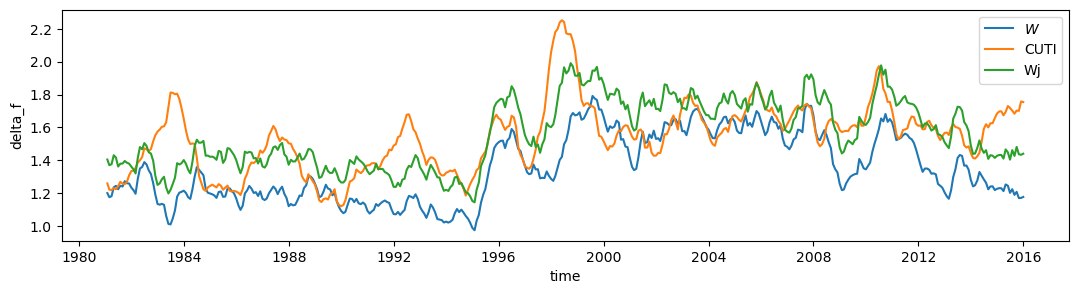

In [63]:
(wmld).WMLD.rolling(time=13).mean().plot(figsize=(13,3),label='$W$')
CUTI.mean(dim=('lon','lat_band')).rolling(time=13).mean().rename('$m^{2} \cdot s^{-1}$').plot(label='CUTI')
(wj*111e3).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='Wj')
plt.legend()

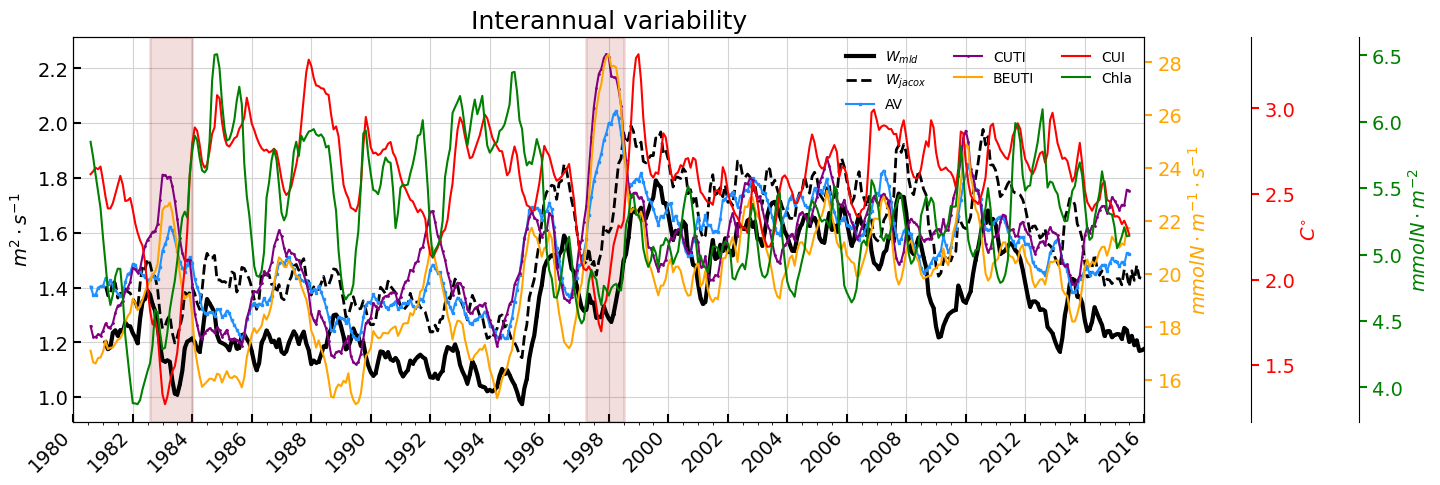

In [65]:
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import datetime

fig, host = plt.subplots(figsize=(18, 5))

# create extra y axes
par1 = host.twinx()
par2 = host.twinx()
par3 = host.twinx()

# offset the extra right spines
par2.spines["right"].set_position(("axes", 1.1))
par3.spines["right"].set_position(("axes", 1.2))

# make their patch/spines invisible (so only the right spine shows)
make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)

par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)

# Plotting (ensure each plot sets label)
W,   = host.plot(time, wmld_m,  linewidth=3, marker='.', markersize=2, color='black',     label='$W_{mld}$')
Wj, =  host.plot(time, wj_m,  linewidth=2, linestyle='dashed', color='black',     label='$W_{jacox}$')

AVi, = host.plot(time, AV_m,    linewidth=1.5, marker='s', markersize=2, color='dodgerblue', label='AV')
BUi, = host.plot(time, BUI_m,   linewidth=1.5, marker='d', markersize=2, color='royalblue',  label='BUI')
CUTi,= host.plot(time, CUTI_m,  linewidth=1.5, marker='.', markersize=2, color='purple',      label='CUTI')

BEUTi, = par1.plot(time, BEUTI_m, linewidth=1.5, color='orange', label='BEUTI')
CUi,   = par2.plot(time,   CUI_m,   linewidth=1.5, color='red',    label='CUI')
Chli,  = par3.plot(time,   CHL_m,   linewidth=1.5, color='green',  label='Chla')

# Labels
# host.set_xlabel('Time')
host.set_ylabel('$m^{2} \cdot s^{-1}$',fontsize=14)
par1.set_ylabel('$mmol N \cdot m^{-1} \cdot s^{-1}$',fontsize=14)
par2.set_ylabel('$C^{\circ}$',fontsize=14)
par3.set_ylabel('$mmol N \cdot m^{-2}$',fontsize=14)

host.yaxis.label.set_color('black')
par1.yaxis.label.set_color('orange')
par2.yaxis.label.set_color('red')
par3.yaxis.label.set_color('green')

# ticks and minor locators
tkw = dict(size=6, width=1.5)
host.xaxis.set_minor_locator(MultipleLocator(100))
host.yaxis.set_minor_locator(MultipleLocator(10))
par1.yaxis.set_minor_locator(MultipleLocator(10))
par2.yaxis.set_minor_locator(MultipleLocator(100))
par3.yaxis.set_minor_locator(MultipleLocator(100))

host.tick_params(axis='y', colors='black', **tkw, labelsize=14)
par1.tick_params(axis='y', colors='orange', **tkw, labelsize=14)
par2.tick_params(axis='y', colors='red', **tkw, labelsize=14)
par3.tick_params(axis='y', colors='green', **tkw, labelsize=14)
host.tick_params(direction='in', **tkw)

# Build legend by collecting handles/labels from all axes
h_host, l_host = host.get_legend_handles_labels()
h_p1, l_p1 = par1.get_legend_handles_labels()
h_p2, l_p2 = par2.get_legend_handles_labels()
h_p3, l_p3 = par3.get_legend_handles_labels()

handles = h_host + h_p1 + h_p2 + h_p3
labels  = l_host + l_p1 + l_p2 + l_p3

# Place legend to the right of the axes
# host.legend(handles, labels, fontsize=10,
#             loc='upper right')
fig.subplots_adjust(right=0.72)

legend = host.legend(
    handles, labels,
    fontsize=10,
    ncol=3,
    # title='Upwelling indices',
    title_fontsize=12,
    frameon=False,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.0)  # optional: place it outside to the right
)


host.grid(True, color='lightgrey', zorder=0)

# ensure host grid is drawn below the plotted lines
# host.set_axisbelow(True)

# Add rectangles for specific date ranges
rectangles = [
    (datetime.datetime(1982, 8, 1), datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1), datetime.datetime(1998, 6, 30))
]

for start_date, end_date in rectangles:
    start_num = mdates.date2num(start_date)
    end_num = mdates.date2num(end_date)
    width = end_num - start_num

    rect = Rectangle(
        (start_num, host.get_ylim()[0]),  # Bottom-left corner
        width,                            # Width in days
        host.get_ylim()[1] - host.get_ylim()[0],  # Full height of y-axis
        linewidth=2,
        edgecolor='firebrick',
        facecolor='firebrick',
        linestyle='-',
        alpha=0.15
    )
    host.add_patch(rect)

# Set x-axis limits (optional, adjust as needed)
host.set_xlim(mdates.date2num(datetime.datetime(1980, 1, 1)),
              mdates.date2num(datetime.datetime(2016, 1, 1)))

# Set major ticks every 2 years and format as year
host.xaxis.set_major_locator(mdates.YearLocator(base=2))
host.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Optionally add minor ticks (e.g., every 6 months)
host.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1,7)))

# Rotate and size tick labels
plt.setp(host.get_xticklabels(), rotation=45, ha='right', fontsize=14)

# Show grid only on host axis (you already have this)
host.grid(True, color='lightgrey', zorder=0)
host.set_axisbelow(True)

plt.title('Interannual variability',fontsize=18)

# plt.savefig('Figures/Interannual_Var.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

### El Nino Extreme Events

#### EN 1982-83

In [66]:
time = wmld.WMLD.sel(time=slice("1981-01-01","1984-12-31")).time

In [67]:
AV_m=AV.mean('lat').resample(time='1M').mean().AV.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1981-01-01","1984-12-31")).data
BUI_m=BUI.mean('lat').resample(time='1M').mean().BUI.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1981-01-01","1984-12-31")).data
wmld_m = wmld.WMLD.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13).mean().sel(time=slice("1981-01-01","1984-12-31")).data
wj_m = (wj*111e3).mean(dim=('lon','lat_band')).rolling(time=13).mean().sel(time=slice("1981-01-01","1984-12-31")).data
CUTI_m=CUTI.mean(dim=('lon','lat_band')).sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1981-01-01","1984-12-31")).data
BEUTI_m=BEUTI.mean(dim=('lon','lat_band')).sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1981-01-01","1984-12-31")).data
CUI_m=CUI.mean('lat').resample(time='1M').mean().sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1981-01-01","1984-12-31")).data
CHL_m=CHL.mean('lat').resample(time='1M').mean().chla.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1981-01-01","1984-12-31")).data

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


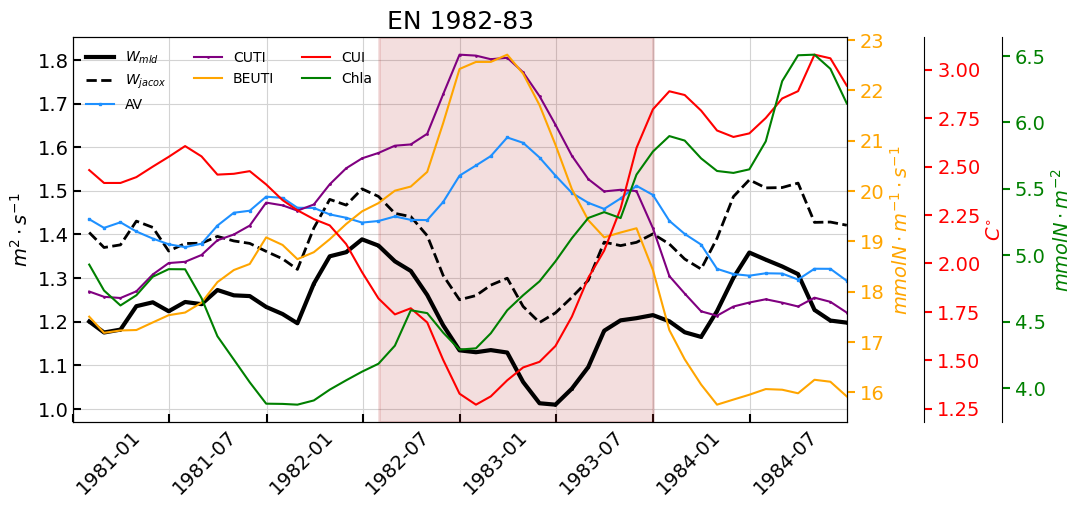

In [68]:
fig, host = plt.subplots(figsize=(13, 5))

# create extra y axes
par1 = host.twinx()
par2 = host.twinx()
par3 = host.twinx()

# offset the extra right spines
par2.spines["right"].set_position(("axes", 1.1))
par3.spines["right"].set_position(("axes", 1.2))

# make their patch/spines invisible (so only the right spine shows)
make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)

par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)

# Plotting (ensure each plot sets label)
W,   = host.plot(time, wmld_m,  linewidth=3, marker='.', markersize=2, color='black',     label='$W_{mld}$')
Wj, =  host.plot(time, wj_m,  linewidth=2, linestyle='dashed', color='black',     label='$W_{jacox}$')

AVi, = host.plot(time, AV_m,    linewidth=1.5, marker='s', markersize=2, color='dodgerblue', label='AV')
BUi, = host.plot(time, BUI_m,   linewidth=1.5, marker='d', markersize=2, color='royalblue',  label='BUI')
CUTi,= host.plot(time, CUTI_m,  linewidth=1.5, marker='.', markersize=2, color='purple',      label='CUTI')

BEUTi, = par1.plot(time, BEUTI_m, linewidth=1.5, color='orange', label='BEUTI')
CUi,   = par2.plot(time,   CUI_m,   linewidth=1.5, color='red',    label='CUI')
Chli,  = par3.plot(time,   CHL_m,   linewidth=1.5, color='green',  label='Chla')

# Labels
# host.set_xlabel('Time')
host.set_ylabel('$m^{2} \cdot s^{-1}$',fontsize=14)
par1.set_ylabel('$mmol N \cdot m^{-1} \cdot s^{-1}$',fontsize=14)
par2.set_ylabel('$C^{\circ}$',fontsize=14)
par3.set_ylabel('$mmol N \cdot m^{-2}$',fontsize=14)

host.yaxis.label.set_color('black')
par1.yaxis.label.set_color('orange')
par2.yaxis.label.set_color('red')
par3.yaxis.label.set_color('green')

# ticks and minor locators
tkw = dict(size=6, width=1.5)
host.xaxis.set_minor_locator(MultipleLocator(100))
host.yaxis.set_minor_locator(MultipleLocator(10))
par1.yaxis.set_minor_locator(MultipleLocator(10))
par2.yaxis.set_minor_locator(MultipleLocator(100))
par3.yaxis.set_minor_locator(MultipleLocator(100))

host.tick_params(axis='y', colors='black', **tkw, labelsize=14)
par1.tick_params(axis='y', colors='orange', **tkw, labelsize=14)
par2.tick_params(axis='y', colors='red', **tkw, labelsize=14)
par3.tick_params(axis='y', colors='green', **tkw, labelsize=14)
host.tick_params(direction='in', **tkw)

# Build legend by collecting handles/labels from all axes
h_host, l_host = host.get_legend_handles_labels()
h_p1, l_p1 = par1.get_legend_handles_labels()
h_p2, l_p2 = par2.get_legend_handles_labels()
h_p3, l_p3 = par3.get_legend_handles_labels()

handles = h_host + h_p1 + h_p2 + h_p3
labels  = l_host + l_p1 + l_p2 + l_p3

# Place legend to the right of the axes
# host.legend(handles, labels, fontsize=10,
#             loc='upper right')
fig.subplots_adjust(right=0.72)

legend = host.legend(
    handles, labels,
    fontsize=10,
    ncol=3,
    # title='Upwelling indices',
    title_fontsize=12,
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(0, 1.0)  # optional: place it outside to the right
)


host.grid(True, color='lightgrey', zorder=0)

# ensure host grid is drawn below the plotted lines
# host.set_axisbelow(True)

# Add rectangles for specific date ranges
rectangles = [
    (datetime.datetime(1982, 8, 1), datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1), datetime.datetime(1998, 6, 30))
]

for start_date, end_date in rectangles:
    start_num = mdates.date2num(start_date)
    end_num = mdates.date2num(end_date)
    width = end_num - start_num

    rect = Rectangle(
        (start_num, host.get_ylim()[0]),  # Bottom-left corner
        width,                            # Width in days
        host.get_ylim()[1] - host.get_ylim()[0],  # Full height of y-axis
        linewidth=2,
        edgecolor='firebrick',
        facecolor='firebrick',
        linestyle='-',
        alpha=0.15
    )
    host.add_patch(rect)

# Set x-axis limits (optional, adjust as needed)  "1981-01-01","1984-12-31"
host.set_xlim(mdates.date2num(datetime.datetime(1981, 1, 1)),
              mdates.date2num(datetime.datetime(1984, 12, 31)))

# Set major ticks every 2 years and format as year
# host.xaxis.set_major_locator(mdates.YearLocator(base=2))
# host.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Optionally add minor ticks (e.g., every 6 months)
host.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1,7)))

# Rotate and size tick labels
plt.setp(host.get_xticklabels(), rotation=45, ha='left', fontsize=14)

# Show grid only on host axis (you already have this)
host.grid(True, color='lightgrey', zorder=0)
host.set_axisbelow(True)

plt.title('EN 1982-83',fontsize=18)

# plt.savefig('Figures/EN_1982-83_noBUI.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

#### EN 1997-98

In [69]:
time = wmld.WMLD.sel(time=slice("1996-01-01","1999-12-31")).time
# time

In [70]:
AV_m=AV.mean('lat').resample(time='1M').mean().AV.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1996-01-01","1999-12-31")).data
BUI_m=BUI.mean('lat').resample(time='1M').mean().BUI.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1996-01-01","1999-12-31")).data
wmld_m = wmld.WMLD.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13).mean().sel(time=slice("1996-01-01","1999-12-31")).data
wj_m = (wj*111e3).mean(dim=('lon','lat_band')).rolling(time=13).mean().sel(time=slice("1996-01-01","1999-12-31")).data
CUTI_m=CUTI.mean(dim=('lon','lat_band')).sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1996-01-01","1999-12-31")).data
BEUTI_m=BEUTI.mean(dim=('lon','lat_band')).sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1996-01-01","1999-12-31")).data
CUI_m=CUI.mean('lat').resample(time='1M').mean().sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1996-01-01","1999-12-31")).data
CHL_m=CHL.mean('lat').resample(time='1M').mean().chla.sel(time=slice('1980-01-01','2015-12-31')).rolling(time=13,center=True).mean().sel(time=slice("1996-01-01","1999-12-31")).data

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


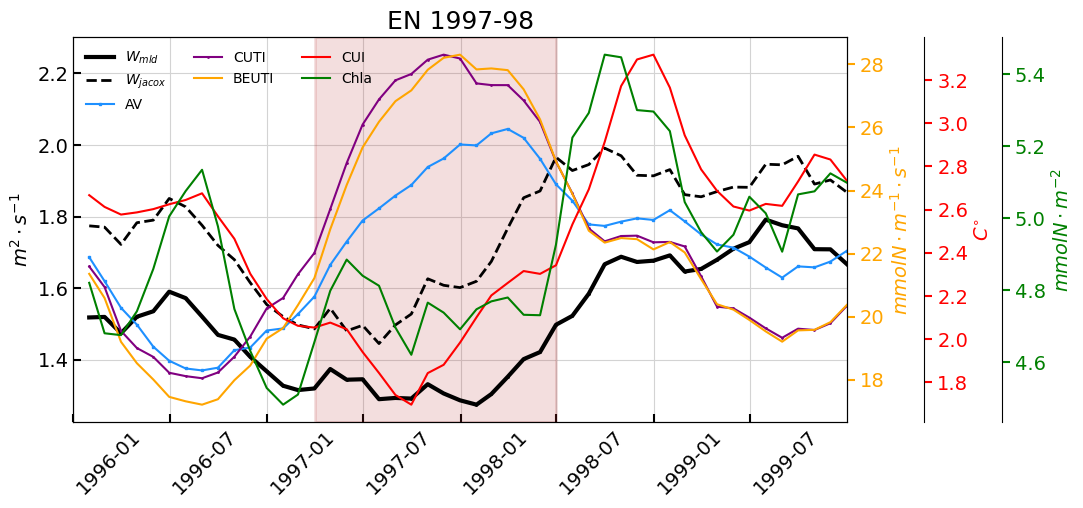

In [71]:
fig, host = plt.subplots(figsize=(13, 5))

# create extra y axes
par1 = host.twinx()
par2 = host.twinx()
par3 = host.twinx()

# offset the extra right spines
par2.spines["right"].set_position(("axes", 1.1))
par3.spines["right"].set_position(("axes", 1.2))

# make their patch/spines invisible (so only the right spine shows)
make_patch_spines_invisible(par2)
make_patch_spines_invisible(par3)

par2.spines["right"].set_visible(True)
par3.spines["right"].set_visible(True)

# Plotting (ensure each plot sets label)
W,   = host.plot(time, wmld_m,  linewidth=3, marker='.', markersize=2, color='black',     label='$W_{mld}$')
Wj, =  host.plot(time, wj_m,  linewidth=2, linestyle='dashed', color='black',     label='$W_{jacox}$')

AVi, = host.plot(time, AV_m,    linewidth=1.5, marker='s', markersize=2, color='dodgerblue', label='AV')
BUi, = host.plot(time, BUI_m,   linewidth=1.5, marker='d', markersize=2, color='royalblue',  label='BUI')
CUTi,= host.plot(time, CUTI_m,  linewidth=1.5, marker='.', markersize=2, color='purple',      label='CUTI')

BEUTi, = par1.plot(time, BEUTI_m, linewidth=1.5, color='orange', label='BEUTI')
CUi,   = par2.plot(time,   CUI_m,   linewidth=1.5, color='red',    label='CUI')
Chli,  = par3.plot(time,   CHL_m,   linewidth=1.5, color='green',  label='Chla')

# Labels
# host.set_xlabel('Time')
host.set_ylabel('$m^{2} \cdot s^{-1}$',fontsize=14)
par1.set_ylabel('$mmol N \cdot m^{-1} \cdot s^{-1}$',fontsize=14)
par2.set_ylabel('$C^{\circ}$',fontsize=14)
par3.set_ylabel('$mmol N \cdot m^{-2}$',fontsize=14)

host.yaxis.label.set_color('black')
par1.yaxis.label.set_color('orange')
par2.yaxis.label.set_color('red')
par3.yaxis.label.set_color('green')

# ticks and minor locators
tkw = dict(size=6, width=1.5)
host.xaxis.set_minor_locator(MultipleLocator(100))
host.yaxis.set_minor_locator(MultipleLocator(10))
par1.yaxis.set_minor_locator(MultipleLocator(10))
par2.yaxis.set_minor_locator(MultipleLocator(100))
par3.yaxis.set_minor_locator(MultipleLocator(100))

host.tick_params(axis='y', colors='black', **tkw, labelsize=14)
par1.tick_params(axis='y', colors='orange', **tkw, labelsize=14)
par2.tick_params(axis='y', colors='red', **tkw, labelsize=14)
par3.tick_params(axis='y', colors='green', **tkw, labelsize=14)
host.tick_params(direction='in', **tkw)

# Build legend by collecting handles/labels from all axes
h_host, l_host = host.get_legend_handles_labels()
h_p1, l_p1 = par1.get_legend_handles_labels()
h_p2, l_p2 = par2.get_legend_handles_labels()
h_p3, l_p3 = par3.get_legend_handles_labels()

handles = h_host + h_p1 + h_p2 + h_p3
labels  = l_host + l_p1 + l_p2 + l_p3

# Place legend to the right of the axes
# host.legend(handles, labels, fontsize=10,
#             loc='upper right')
fig.subplots_adjust(right=0.72)

legend = host.legend(
    handles, labels,
    fontsize=10,
    ncol=3,
    # title='Upwelling indices',
    title_fontsize=12,
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(0, 1.0)  # optional: place it outside to the right
)


host.grid(True, color='lightgrey', zorder=0)

# ensure host grid is drawn below the plotted lines
# host.set_axisbelow(True)

# Add rectangles for specific date ranges
rectangles = [
    (datetime.datetime(1982, 8, 1), datetime.datetime(1983, 12, 31)),
    (datetime.datetime(1997, 4, 1), datetime.datetime(1998, 6, 30))
]

for start_date, end_date in rectangles:
    start_num = mdates.date2num(start_date)
    end_num = mdates.date2num(end_date)
    width = end_num - start_num

    rect = Rectangle(
        (start_num, host.get_ylim()[0]),  # Bottom-left corner
        width,                            # Width in days
        host.get_ylim()[1] - host.get_ylim()[0],  # Full height of y-axis
        linewidth=2,
        edgecolor='firebrick',
        facecolor='firebrick',
        linestyle='-',
        alpha=0.15
    )
    host.add_patch(rect)

# Set x-axis limits (optional, adjust as needed)  "1996-01-01","1999-12-31"
host.set_xlim(mdates.date2num(datetime.datetime(1996, 1, 1)),
              mdates.date2num(datetime.datetime(1999, 12, 31)))

# Set major ticks every 2 years and format as year
# host.xaxis.set_major_locator(mdates.YearLocator(base=2))
# host.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Optionally add minor ticks (e.g., every 6 months)
host.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1,7)))

# Rotate and size tick labels
plt.setp(host.get_xticklabels(), rotation=45, ha='left', fontsize=14)

# Show grid only on host axis (you already have this)
host.grid(True, color='lightgrey', zorder=0)
host.set_axisbelow(True)

plt.title('EN 1997-98',fontsize=18)

# plt.savefig('Figures/EN_1997-98.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## Yearly scale